In [2]:
# @title 0. 环境设置与依赖项安装
# ------------------------------------------------------------------------------
# 清理、克隆、添加路径 (与之前一致)
# ------------------------------------------------------------------------------
!rm -rf /content/Time-Series-Library
!rm -rf /content/NAB
print("Cleaned up any existing Time-Series-Library and NAB directories.")
!git clone https://github.com/thuml/Time-Series-Library.git /content/Time-Series-Library -q
print("Time-Series-Library (containing TimesNet) repository cloned.")
!git clone https://github.com/numenta/NAB.git /content/NAB -q
print("NAB repository cloned.")
import sys
TIMESNET_PATH = '/content/Time-Series-Library'
if TIMESNET_PATH not in sys.path: sys.path.insert(0, TIMESNET_PATH)
print(f"Path '{TIMESNET_PATH}' added to sys.path.")

# ------------------------------------------------------------------------------
# 安装必要的依赖 (不再需要 statsmodels)
# ------------------------------------------------------------------------------
!pip install einops pandas numpy matplotlib scikit-learn torch torchvision torchaudio sympy -q
print("Installed/checked necessary packages.")

# ------------------------------------------------------------------------------
# 导入标准库
# ------------------------------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler # 保留两者以供选择
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import json
import os
print("Imported standard libraries.")

# ------------------------------------------------------------------------------
# 导入 TimesNet 模型类 (与之前一致)
# ------------------------------------------------------------------------------
try:
    from models.TimesNet import Model as TimesNetModel
    print("Successfully imported TimesNet model class as TimesNetModel.")
except ImportError as e: print(f"ERROR: Could not import TimesNet model: {e}"); raise
except Exception as e_other: print(f"An unexpected error occurred during TimesNet import: {e_other}"); raise

# ------------------------------------------------------------------------------
# 设置设备 (与之前一致)
# ------------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------------------------
# 打印环境信息 (与之前一致)
# ------------------------------------------------------------------------------
print(f"\n--- Environment Setup ---")
print(f"Using device: {device}")
print(f"PyTorch Version: {torch.__version__}")
# ... (CUDA info printout) ...
print(f"--- Setup Complete ---")

Cleaned up any existing Time-Series-Library and NAB directories.
Time-Series-Library (containing TimesNet) repository cloned.
NAB repository cloned.
Path '/content/Time-Series-Library' added to sys.path.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 122.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 101.8 MB/s eta 0:00:

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


--- Data Loading and Label Processing (NAB Dataset) ---
Attempting to load data for: realAWSCloudwatch/ec2_network_in_257a54.csv
Successfully loaded data from: /content/NAB/data/realAWSCloudwatch/ec2_network_in_257a54.csv
Found 1 raw anomaly window(s).
Label processing complete. Processed 1 window(s).
Total points marked as anomalous: 403

Prepared 'raw_time_series_values' (shape: (4032,)).
Prepared 'pointwise_true_labels' (anomalies: 403).


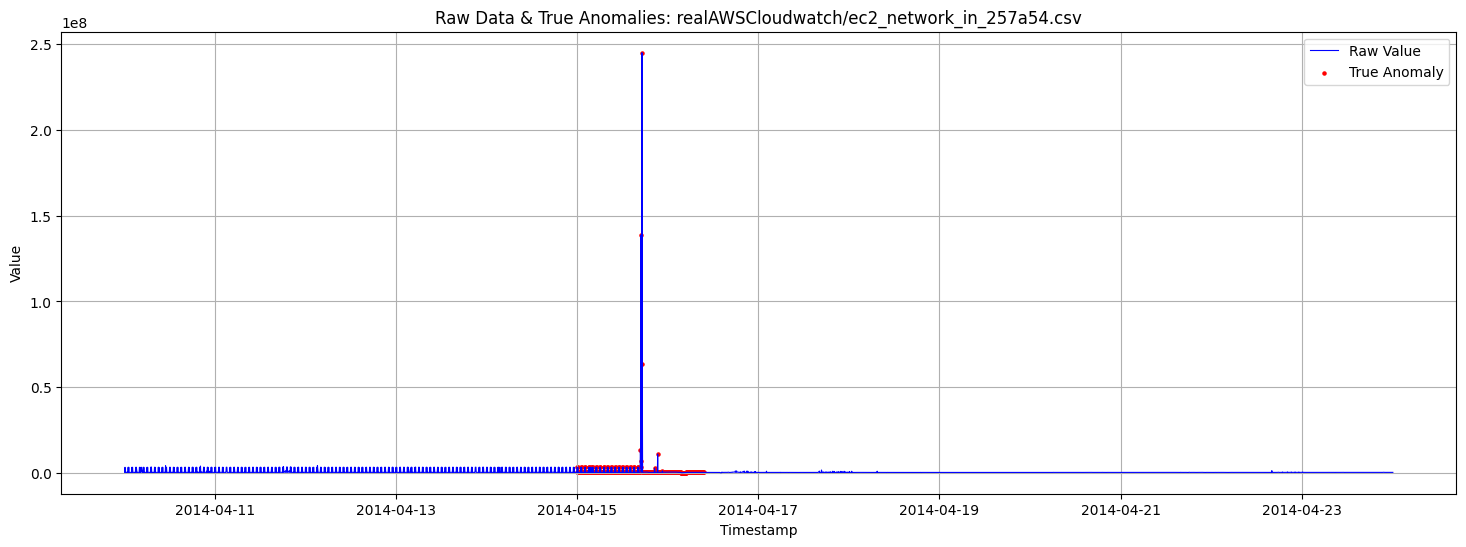

--- Data Loading and Label Processing Complete ---


In [4]:
# @title 1. NAB 数据加载与标签处理
# ------------------------------------------------------------------------------
# 用户指定参数
# ------------------------------------------------------------------------------
NAB_DATA_FILE_RELATIVE_PATH = 'realAWSCloudwatch/ec2_network_in_257a54.csv' # <--- 您选择的数据文件

DATA_FILE_COLAB_PATH = f'/content/NAB/data/{NAB_DATA_FILE_RELATIVE_PATH}'
LABEL_FILE_COLAB_PATH = '/content/NAB/labels/combined_windows.json'
JSON_KEY_FOR_LABELS = NAB_DATA_FILE_RELATIVE_PATH

print(f"--- Data Loading and Label Processing (NAB Dataset) ---")
print(f"Attempting to load data for: {NAB_DATA_FILE_RELATIVE_PATH}")

data_df = None
raw_time_series_values = None
pointwise_true_labels = None

if not os.path.exists(DATA_FILE_COLAB_PATH):
    print(f"ERROR: Data file not found: {DATA_FILE_COLAB_PATH}")
else:
    try:
        data_df_loaded = pd.read_csv(DATA_FILE_COLAB_PATH)
        print(f"Successfully loaded data from: {DATA_FILE_COLAB_PATH}")
        if 'timestamp' not in data_df_loaded.columns: raise ValueError("Column 'timestamp' not found.")
        data_df_loaded['timestamp'] = pd.to_datetime(data_df_loaded['timestamp'])
        data_df_loaded = data_df_loaded.set_index('timestamp')
        if 'value' not in data_df_loaded.columns: raise ValueError("Column 'value' not found.")
        data_df = data_df_loaded.copy() # Assign to data_df only after successful load and checks

        # Ensure 'value' column is numeric
        if not pd.api.types.is_numeric_dtype(data_df['value']):
             print(f"Warning: 'value' column is not numeric. Attempting conversion...")
             data_df['value'] = pd.to_numeric(data_df['value'], errors='coerce')
             if data_df['value'].isnull().all(): raise ValueError("'value' column is all NaN after conversion.")

    except Exception as e:
        print(f"Error during data loading or initial processing: {e}")
        data_df = None

if data_df is not None and 'value' in data_df.columns and not data_df['value'].isnull().all():
    # --- Label Processing Logic (identical to before) ---
    data_df['is_anomaly_pointwise'] = 0
    parsed_anomaly_windows_count = 0
    if not os.path.exists(LABEL_FILE_COLAB_PATH):
        print(f"WARNING: Label file not found: {LABEL_FILE_COLAB_PATH}.")
    else:
        try:
            with open(LABEL_FILE_COLAB_PATH, 'r') as f: all_labels_json = json.load(f)
            raw_anomaly_windows_list = all_labels_json.get(JSON_KEY_FOR_LABELS, [])
            if not raw_anomaly_windows_list: print(f"No anomaly windows found for key '{JSON_KEY_FOR_LABELS}'.")
            else:
                print(f"Found {len(raw_anomaly_windows_list)} raw anomaly window(s).")
                for window_event in raw_anomaly_windows_list:
                     if isinstance(window_event, list) and len(window_event) == 2:
                        try:
                            start_ts_str, end_ts_str = window_event
                            start_ts = pd.to_datetime(start_ts_str, errors='coerce')
                            end_ts = pd.to_datetime(end_ts_str, errors='coerce')
                            if pd.isna(start_ts) or pd.isna(end_ts): raise ValueError(f"Failed parse: {start_ts_str}, {end_ts_str}")
                            mask = (data_df.index >= start_ts) & (data_df.index <= end_ts)
                            data_df.loc[mask, 'is_anomaly_pointwise'] = 1
                            if mask.sum() > 0: parsed_anomaly_windows_count += 1
                        except Exception as e_win: print(f"  Warn: Couldn't process window {window_event}: {e_win}")
                print(f"Label processing complete. Processed {parsed_anomaly_windows_count} window(s).")
                print(f"Total points marked as anomalous: {data_df['is_anomaly_pointwise'].sum()}")
        except Exception as e_label: print(f"Label processing error: {e_label}")
    # --- End Label Processing ---

    raw_time_series_values = data_df['value'].values.copy() # Store original raw values
    pointwise_true_labels = data_df['is_anomaly_pointwise'].values.copy()
    print(f"\nPrepared 'raw_time_series_values' (shape: {raw_time_series_values.shape}).")
    print(f"Prepared 'pointwise_true_labels' (anomalies: {pointwise_true_labels.sum()}).")

    # --- Plotting Raw Data (identical to before) ---
    plt.figure(figsize=(18, 6))
    plt.plot(data_df.index, data_df['value'], label='Raw Value', color='blue', linewidth=0.8)
    anomalies_plot = data_df[data_df['is_anomaly_pointwise'] == 1]
    if not anomalies_plot.empty: plt.scatter(anomalies_plot.index, anomalies_plot['value'], color='red', label='True Anomaly', marker='.', s=20)
    plt.title(f"Raw Data & True Anomalies: {JSON_KEY_FOR_LABELS}"); plt.xlabel("Timestamp"); plt.ylabel("Value"); plt.legend(); plt.grid(True); plt.show()
    # --- End Plotting ---

elif data_df is not None: print("ERROR: 'value' column missing or all NaN.")
else: print("Data loading failed.")

print(f"--- Data Loading and Label Processing Complete ---")


--- Differencing Preprocessing (on Raw Data) ---
Applying 1-order differencing to the raw data...
Differencing complete. Resulting series length: 4031
Labels successfully aligned. Aligned labels length: 4031, Anomalies: 403


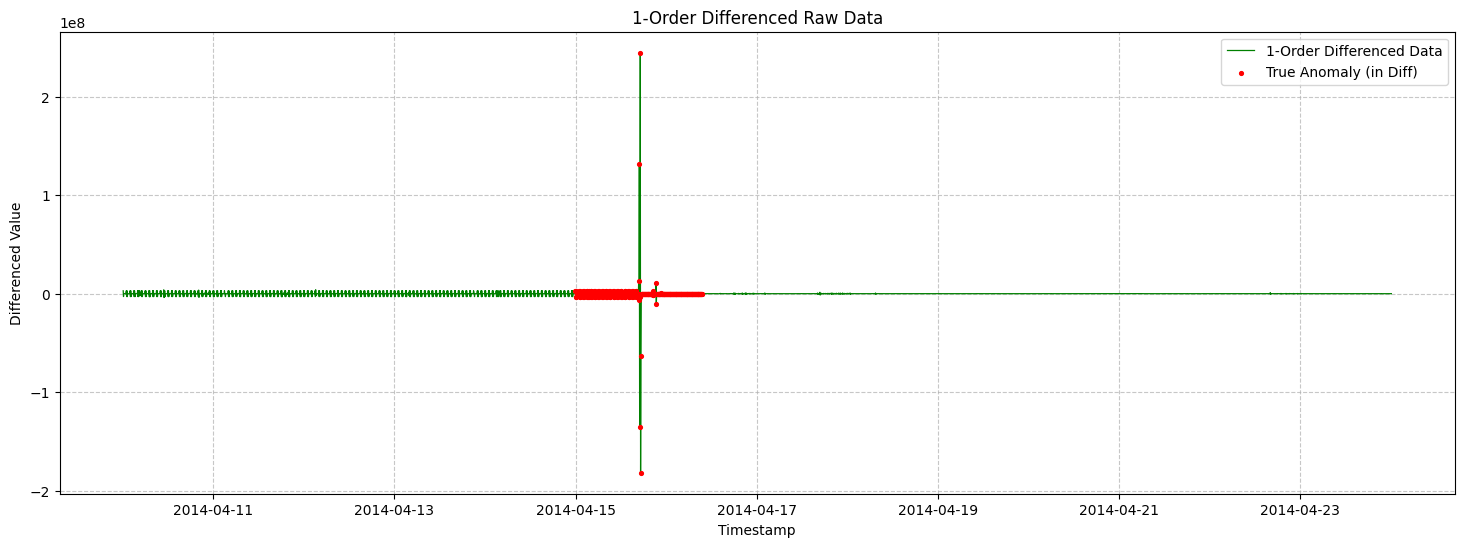

--- Differencing Preprocessing Complete ---


In [5]:
# @title 2. 差分处理 (应用于原始数据)
# ------------------------------------------------------------------------------
# 直接对原始时间序列 data_df['value'] 应用差分处理
# ------------------------------------------------------------------------------
print(f"\n--- Differencing Preprocessing (on Raw Data) ---")

raw_diff_values = None # 将持有差分后的数据值
pointwise_true_labels_aligned = None # 对齐差分后序列的标签
df_diff = None # 可选的包含差分数据的DataFrame
diff_order = 1 # <--- 差分阶数 (1 for first-order, 2 for second-order, etc.)

# 确保 data_df['value'] 和原始标签存在且有效
if data_df is not None and 'value' in data_df.columns and not data_df['value'].isnull().all() and pointwise_true_labels is not None:

    # --- Differencing ---
    print(f"Applying {diff_order}-order differencing to the raw data...")

    # 计算差分，并移除因差分产生的NaN值
    # .diff() 默认 periods=1 (一阶差分)
    diff_series = data_df['value'].diff(periods=diff_order).dropna()

    if diff_series.empty:
        print("ERROR: Differencing resulted in an empty series. Check data or diff_order.")
        raw_diff_values = None
        pointwise_true_labels_aligned = None
    else:
        raw_diff_values = diff_series.values
        print(f"Differencing complete. Resulting series length: {len(raw_diff_values)}")

        # --- 对齐标签 ---
        # 差分操作移除了前 'diff_order' 个点，所以标签也需要移除前 'diff_order' 个
        if len(pointwise_true_labels) >= diff_order:
            pointwise_true_labels_aligned = pointwise_true_labels[diff_order:]
            # 验证长度是否匹配
            if len(raw_diff_values) == len(pointwise_true_labels_aligned):
                print(f"Labels successfully aligned. Aligned labels length: {len(pointwise_true_labels_aligned)}, Anomalies: {pointwise_true_labels_aligned.sum()}")
            else:
                # This case should theoretically not happen if diff().dropna() works as expected
                print(f"ERROR: Length mismatch after label alignment! Diff values: {len(raw_diff_values)}, Aligned labels: {len(pointwise_true_labels_aligned)}. Cannot proceed reliably.")
                raw_diff_values = None # Mark as unusable
                pointwise_true_labels_aligned = None
        else:
            print(f"ERROR: Original labels array (length {len(pointwise_true_labels)}) is too short for differencing order {diff_order}.")
            raw_diff_values = None
            pointwise_true_labels_aligned = None

        # --- 可视化差分结果 ---
        if raw_diff_values is not None:
            # 创建包含差分数据的 DataFrame (使用与原始数据对齐的索引)
            df_diff = pd.DataFrame({'value_diff': raw_diff_values}, index=diff_series.index)

            plt.figure(figsize=(18, 6))
            plt.plot(df_diff.index, df_diff['value_diff'], label=f'{diff_order}-Order Differenced Data', color='green', linewidth=0.9)

            # 可选：标记差分数据中的异常点（基于对齐后的标签）
            if pointwise_true_labels_aligned is not None and len(df_diff) == len(pointwise_true_labels_aligned):
                 anomalies_in_diff = df_diff[pointwise_true_labels_aligned == 1]
                 if not anomalies_in_diff.empty:
                     plt.scatter(anomalies_in_diff.index, anomalies_in_diff['value_diff'], color='red', label='True Anomaly (in Diff)', marker='.', s=30, zorder=5)

            plt.title(f'{diff_order}-Order Differenced Raw Data')
            plt.xlabel('Timestamp')
            plt.ylabel('Differenced Value')
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.show()

            # 可选：将差分结果（带正确索引）添加回原始 df (如果需要的话)
            # 注意：添加回去会导致列长不一致，除非特殊处理，一般不直接 join
            # data_df = data_df.join(df_diff) # Be careful with this due to length difference

else:
    print("Raw data ('value' column in data_df) or original labels not available/valid. Skipping differencing.")
    raw_diff_values = None
    pointwise_true_labels_aligned = None

print(f"--- Differencing Preprocessing Complete ---")

In [6]:
# @title 3. 数据准备 (缩放、窗口化、标签 - 基于差分后数据)
# ------------------------------------------------------------------------------
# 使用差分后的数据 和 对齐后的标签 作为 TimesNet 的输入
# ------------------------------------------------------------------------------
print(f"\n--- Data Preparation for TimesNet (Scaling, Windowing, Labels on Differenced Data) ---")
X_tensor = None
dataloader = None
window_level_true_labels_for_model = None # 窗口标签基于对齐后的点标签
WINDOW_SIZE = None
time_series_for_model_scaled = None
X_windowed_data_np = None
input_series_for_timesnet = None

# 决定使用哪个时间序列进行 TimesNet 输入
# 在此流程中，我们必须使用差分数据（如果成功生成）
if raw_diff_values is not None and pointwise_true_labels_aligned is not None:
    print("Using differenced data as input for TimesNet.")
    input_series_for_timesnet = raw_diff_values # 使用差分结果
    # 差分数据本身不应引入新的内部 NaN，除非原始数据有 NaN
else:
    print("ERROR: Differenced data or aligned labels are not available from Module 2. Cannot proceed.")
    input_series_for_timesnet = None

# --- 后续处理: NaN填充(以防万一), 缩放, 窗口化, DataLoader创建 ---
if input_series_for_timesnet is not None:
    # 1. 确保是一维并填充NaN (以防原始数据中的NaN导致差分结果含NaN)
    temp_series_pd = pd.Series(input_series_for_timesnet.flatten())
    # 差分数据可能包含大的正负值，用0填充NaN可能比较中性
    if temp_series_pd.isnull().any():
        print("Warning: Filling NaNs found in differenced series with 0 before scaling.")
        temp_series_pd.fillna(0, inplace=True)
    input_series_for_timesnet_filled = temp_series_pd.values.reshape(-1, 1)

    # 2. 检查数据是否为空
    if input_series_for_timesnet_filled.size == 0:
        print("ERROR: Input series is empty after NaN handling. Cannot proceed.")
        input_series_for_timesnet = None # 重置为 None

if input_series_for_timesnet is not None and input_series_for_timesnet_filled.size > 0 and pointwise_true_labels_aligned is not None:
    # 3. 缩放 (StandardScaler 通常更适合差分数据)
    # scaler = MinMaxScaler(feature_range=(0, 1))
    scaler = StandardScaler() # 推荐对差分数据使用标准化
    print(f"Using {type(scaler).__name__} for scaling.")
    time_series_for_model_scaled = scaler.fit_transform(input_series_for_timesnet_filled)
    print(f"Input data for TimesNet (based on differenced raw) scaled. Shape: {time_series_for_model_scaled.shape}")

    # 4. 窗口化和 DataLoader 创建
    WINDOW_SIZE = 96 # 常用值, 可调
    print(f"Using WINDOW_SIZE (seq_len for TimesNet): {WINDOW_SIZE}")

    if len(time_series_for_model_scaled) < WINDOW_SIZE:
        print(f"ERROR: Data length ({len(time_series_for_model_scaled)}) < WINDOW_SIZE ({WINDOW_SIZE}).")
    else:
        def create_windows_for_timesnet(input_data, window_length): # (Function same as before)
            windows = []
            for i in range(len(input_data) - window_length + 1):
                windows.append(input_data[i : i + window_length])
            return np.array(windows)

        X_windowed_data_np = create_windows_for_timesnet(time_series_for_model_scaled, WINDOW_SIZE)

        if X_windowed_data_np.shape[0] > 0:
            print(f"Created windows. Shape: {X_windowed_data_np.shape}")
            X_tensor = torch.tensor(X_windowed_data_np, dtype=torch.float32).to(device)
            y_tensor_target = X_tensor.detach().clone() # 重构目标
            print(f"X_tensor shape: {X_tensor.shape}, y_tensor_target shape: {y_tensor_target.shape}")

            # 创建窗口级别标签 (!!! 使用对齐后的 pointwise_true_labels_aligned !!!)
            num_windows = X_windowed_data_np.shape[0]; temp_window_labels = []
            if len(pointwise_true_labels_aligned) >= WINDOW_SIZE:
                 for i in range(num_windows):
                     if i + WINDOW_SIZE <= len(pointwise_true_labels_aligned):
                         aligned_labels_in_window = pointwise_true_labels_aligned[i : i + WINDOW_SIZE]
                         is_anom = np.any(aligned_labels_in_window == 1)
                         temp_window_labels.append(1 if is_anom else 0)
                     else: temp_window_labels.append(0) # Safety
                 window_level_true_labels_for_model = np.array(temp_window_labels)
                 print(f"Created window labels from aligned labels. Shape: {window_level_true_labels_for_model.shape}, Anomalous windows: {window_level_true_labels_for_model.sum()}")
            else: print(f"Warn: Aligned labels too short for windowing."); window_level_true_labels_for_model = np.zeros(num_windows, dtype=int)

            # 创建 DataLoader
            BATCH_SIZE_MODEL = 32
            dataset = TensorDataset(X_tensor, y_tensor_target)
            dataloader = DataLoader(dataset, batch_size=BATCH_SIZE_MODEL, shuffle=True)
            print(f"DataLoader created with batch size {BATCH_SIZE_MODEL}.")
        else: print("No windows were created (input data too short?).")
else: print("Skipping TimesNet data preparation: Differenced input or aligned labels are not valid.")

print(f"--- Data Preparation for TimesNet (on Differenced Data) Complete ---")


--- Data Preparation for TimesNet (Scaling, Windowing, Labels on Differenced Data) ---
Using differenced data as input for TimesNet.
Using StandardScaler for scaling.
Input data for TimesNet (based on differenced raw) scaled. Shape: (4031, 1)
Using WINDOW_SIZE (seq_len for TimesNet): 96
Created windows. Shape: (3936, 96, 1)
X_tensor shape: torch.Size([3936, 96, 1]), y_tensor_target shape: torch.Size([3936, 96, 1])
Created window labels from aligned labels. Shape: (3936,), Anomalous windows: 498
DataLoader created with batch size 32.
--- Data Preparation for TimesNet (on Differenced Data) Complete ---


In [7]:
# @title 4. TimesNet 模型定义
# ------------------------------------------------------------------------------
print(f"\n--- TimesNet Model Definition ---")
model = None
if WINDOW_SIZE is not None and X_tensor is not None and X_tensor.nelement() > 0 :
    class TimesNetConfigs: # (Config class definition identical to before)
        def __init__(self, current_window_size, num_features=1):
            self.seq_len = current_window_size; self.pred_len = 0
            self.enc_in = num_features; self.c_out = num_features
            self.d_model = 64; self.d_ff = 64; self.num_kernels = 6
            self.e_layers = 2; self.top_k = 5; self.dropout = 0.1
            self.task_name = 'anomaly_detection'; self.embed = 'fixed'
            self.freq = 'h'; self.output_attention = False; self.label_len = 0
    try:
        n_features_model = 1 # Assuming univariate
        model_configs = TimesNetConfigs(WINDOW_SIZE, num_features=n_features_model)
        model = TimesNetModel(model_configs).float().to(device)
        print("TimesNet model instantiated.")
        if list(model.parameters()): print(f"Model is on device: {next(model.parameters()).device}")
        else: print("Warning: Model has no parameters.")
    except Exception as e_model_init: print(f"ERROR instantiating TimesNet: {e_model_init}"); model = None
else: print("Cannot instantiate TimesNet model: Check Module 3 for WINDOW_SIZE or X_tensor.")
print(f"--- Model Definition Complete ---")


--- TimesNet Model Definition ---
TimesNet model instantiated.
Model is on device: cuda:0
--- Model Definition Complete ---



--- Model Training (TimesNet for Reconstruction) ---
Starting training TimesNet for 10 epochs...
Epoch [1/10], Loss: 0.2826788
Epoch [2/10], Loss: 0.0588172
Epoch [3/10], Loss: 0.0189833
Epoch [4/10], Loss: 0.0079175
Epoch [5/10], Loss: 0.0099221
Epoch [6/10], Loss: 0.0050956
Epoch [7/10], Loss: 0.0032964
Epoch [8/10], Loss: 0.0097493
Epoch [9/10], Loss: 0.0053049
Epoch [10/10], Loss: 0.0028954
Training finished.


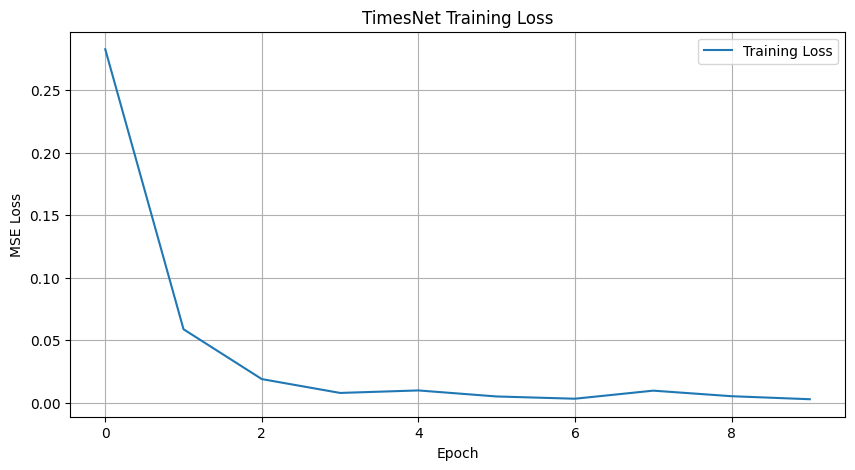

--- Model Training Complete ---


In [8]:
# @title 5. 模型训练 (TimesNet for Reconstruction)
# ------------------------------------------------------------------------------
print(f"\n--- Model Training (TimesNet for Reconstruction) ---")
history = {'train_loss': []}
if model is not None and dataloader is not None :
    NUM_EPOCHS_TIMESNET = 10; LEARNING_RATE_TIMESNET = 0.001
    criterion = nn.MSELoss(); optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE_TIMESNET)
    print(f"Starting training TimesNet for {NUM_EPOCHS_TIMESNET} epochs...")
    for epoch in range(NUM_EPOCHS_TIMESNET): # (Training loop identical to before)
        model.train(); epoch_loss = 0
        for batch_x, batch_y_true_reconstruction in dataloader:
            optimizer.zero_grad()
            dec_inp_dummy = torch.zeros_like(batch_x).float().to(device)
            outputs = model(batch_x, None, dec_inp_dummy, None)
            loss = criterion(outputs, batch_y_true_reconstruction)
            loss.backward(); optimizer.step(); epoch_loss += loss.item()
        avg_epoch_loss = epoch_loss / len(dataloader); history['train_loss'].append(avg_epoch_loss)
        if (epoch + 1) % 1 == 0 or epoch == NUM_EPOCHS_TIMESNET - 1 : print(f"Epoch [{epoch+1}/{NUM_EPOCHS_TIMESNET}], Loss: {avg_epoch_loss:.7f}")
    print("Training finished.")
    plt.figure(figsize=(10, 5)); plt.plot(history['train_loss'], label='Training Loss'); plt.title('TimesNet Training Loss'); plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.legend(); plt.grid(True); plt.show()
else: print("Skipping model training: model or dataloader not available.")
print(f"--- Model Training Complete ---")


--- Anomaly Score Calculation (TimesNet Reconstruction Error on Differenced Data) ---
Calculated anomaly scores for 3936 sequences.
Anomaly scores mapped to time points (of the differenced series).


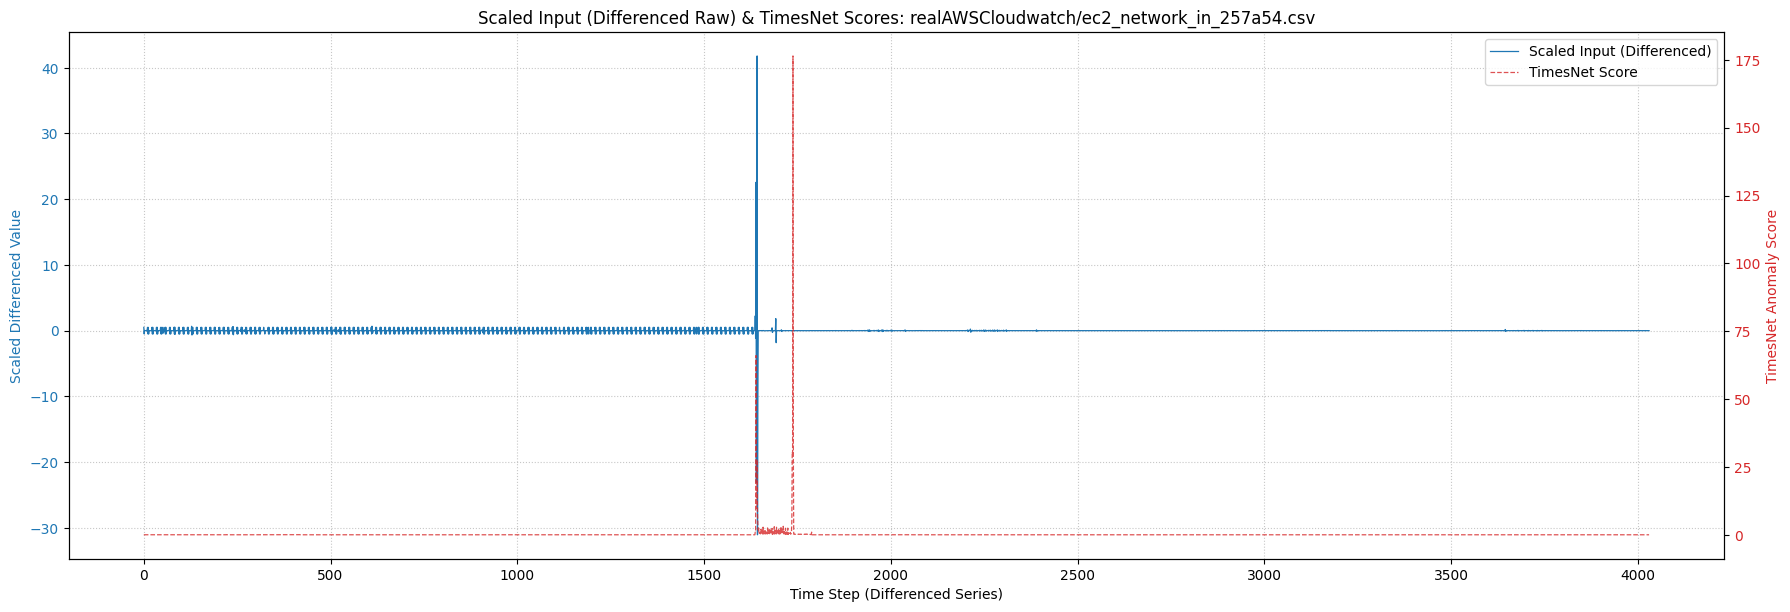

--- Anomaly Score Calculation Complete ---


In [9]:
# @title 6. 异常分数计算 (TimesNet 重构误差)
# ------------------------------------------------------------------------------
print(f"\n--- Anomaly Score Calculation (TimesNet Reconstruction Error on Differenced Data) ---")
anomaly_scores_per_sequence = None
anomaly_scores_timesnet_pointwise = None # 这个是对应 *差分后* 序列的时间点的分数

if (model is not None and X_tensor is not None and X_tensor.size(0) > 0 and WINDOW_SIZE is not None and time_series_for_model_scaled is not None and len(time_series_for_model_scaled) > 0):
    # (Score calculation logic identical to before)
    model.eval(); temp_anomaly_scores_per_sequence = []
    eval_dataset_tsn = TensorDataset(X_tensor, X_tensor)
    eval_dataloader_tsn = DataLoader(eval_dataset_tsn, batch_size=BATCH_SIZE_MODEL, shuffle=False)
    reconstruction_criterion_none = nn.MSELoss(reduction='none').to(device)
    with torch.no_grad():
        for batch_x, _ in eval_dataloader_tsn:
            dec_inp_dummy_eval = torch.zeros_like(batch_x).float().to(device)
            reconstruction = model(batch_x, None, dec_inp_dummy_eval, None)
            loss_pointwise = reconstruction_criterion_none(reconstruction, batch_x)
            loss_per_timestep = loss_pointwise.mean(dim=-1)
            current_batch_anomaly_scores = loss_per_timestep.max(dim=-1)[0]
            temp_anomaly_scores_per_sequence.extend(current_batch_anomaly_scores.cpu().numpy())
    anomaly_scores_per_sequence = np.array(temp_anomaly_scores_per_sequence)
    print(f"Calculated anomaly scores for {len(anomaly_scores_per_sequence)} sequences.")

    # --- Map scores back to time points (of the differenced series) ---
    anomaly_scores_timesnet_pointwise = np.full(len(time_series_for_model_scaled), np.nan)
    num_expected_sequences = len(time_series_for_model_scaled) - WINDOW_SIZE + 1
    # (Mapping logic identical, maps to the scaled differenced series)
    if len(anomaly_scores_per_sequence) == num_expected_sequences:
        for i in range(len(anomaly_scores_per_sequence)): anomaly_scores_timesnet_pointwise[i + WINDOW_SIZE - 1] = anomaly_scores_per_sequence[i]
        first_valid = np.where(~np.isnan(anomaly_scores_timesnet_pointwise))[0]
        if len(first_valid) > 0: anomaly_scores_timesnet_pointwise[:first_valid[0]] = anomaly_scores_timesnet_pointwise[first_valid[0]]
        else: anomaly_scores_timesnet_pointwise[:] = 0
        print("Anomaly scores mapped to time points (of the differenced series).")
    # (Fallback logic for length mismatch identical)
    elif len(anomaly_scores_per_sequence) > 0 :
        print(f"Warn: Score length mismatch. Expected {num_expected_sequences}, got {len(anomaly_scores_per_sequence)}. Partial fill.")
        fill_len = min(len(anomaly_scores_per_sequence), num_expected_sequences)
        if fill_len > 0 :
            for i in range(fill_len): anomaly_scores_timesnet_pointwise[i + WINDOW_SIZE - 1] = anomaly_scores_per_sequence[i]
            first_valid = np.where(~np.isnan(anomaly_scores_timesnet_pointwise))[0]
            if len(first_valid) > 0: anomaly_scores_timesnet_pointwise[:first_valid[0]] = anomaly_scores_timesnet_pointwise[first_valid[0]]
            else: anomaly_scores_timesnet_pointwise[:] = 0
        else: anomaly_scores_timesnet_pointwise[:] = 0
        print("Partial mapping complete.")
    else:
        print("No scores calculated. Filling with zeros.")
        anomaly_scores_timesnet_pointwise = np.zeros(len(time_series_for_model_scaled))
    # --- End Mapping ---

    # --- Plotting Scores vs Scaled *Differenced* Input ---
    if (time_series_for_model_scaled is not None and len(time_series_for_model_scaled) > 0 and anomaly_scores_timesnet_pointwise is not None and len(anomaly_scores_timesnet_pointwise) == len(time_series_for_model_scaled)):
        fig, ax1 = plt.subplots(figsize=(18, 6))
        color = 'tab:blue'; ax1.set_xlabel('Time Step (Differenced Series)'); ax1.set_ylabel('Scaled Differenced Value', color=color)
        ax1.plot(time_series_for_model_scaled, color=color, label='Scaled Input (Differenced)', linewidth=0.9); ax1.tick_params(axis='y', labelcolor=color); ax1.grid(True, linestyle=':', alpha=0.7)
        ax2 = ax1.twinx(); color = 'tab:red'; ax2.set_ylabel('TimesNet Anomaly Score', color=color)
        ax2.plot(anomaly_scores_timesnet_pointwise, color=color, label='TimesNet Score', linestyle='--', linewidth=0.9, alpha=0.8); ax2.tick_params(axis='y', labelcolor=color)
        fig.tight_layout(); plt.title(f'Scaled Input (Differenced Raw) & TimesNet Scores: {NAB_DATA_FILE_RELATIVE_PATH}')
        lines, labels = ax1.get_legend_handles_labels(); lines2, labels2 = ax2.get_legend_handles_labels(); ax2.legend(lines + lines2, labels + labels2, loc='best'); plt.show()
    else: print("Could not plot scores: data missing or lengths mismatch.")
    # --- End Plotting ---
else: print("Skipping score calculation: prerequisites not met.")
print(f"--- Anomaly Score Calculation Complete ---")

In [10]:
# @title 7. 阈值设定与评估 (窗口级别 - TimesNet)
# ------------------------------------------------------------------------------
# 使用 对齐后的标签 window_level_true_labels_for_model 进行评估
# ------------------------------------------------------------------------------
print(f"\n--- Thresholding and Evaluation (TimesNet on Window-Level) ---")
predicted_window_anomalies_bool_tsn = None
# 确保 anomaly_scores_per_sequence 和 window_level_true_labels_for_model (来自对齐标签) 都有效
if (anomaly_scores_per_sequence is not None and window_level_true_labels_for_model is not None and len(anomaly_scores_per_sequence) == len(window_level_true_labels_for_model) and len(window_level_true_labels_for_model) > 0 and WINDOW_SIZE is not None):
    threshold_percentile = 0.95 # (Thresholding logic identical)
    if len(anomaly_scores_per_sequence) > 0: threshold_timesnet = np.quantile(anomaly_scores_per_sequence, threshold_percentile)
    else: threshold_timesnet = 0
    print(f"Anomaly threshold ({threshold_percentile*100:.0f}th percentile): {threshold_timesnet:.6f}")
    predicted_window_anomalies_bool_tsn = anomaly_scores_per_sequence > threshold_timesnet
    predicted_window_anomalies_int_tsn = predicted_window_anomalies_bool_tsn.astype(int)
    # (Evaluation metric calculation identical, uses aligned window labels)
    precision, recall, f1, _ = precision_recall_fscore_support(window_level_true_labels_for_model, predicted_window_anomalies_int_tsn, average='binary', zero_division=0)
    cm = confusion_matrix(window_level_true_labels_for_model, predicted_window_anomalies_int_tsn)
    print(f"\nEvaluation Results (TimesNet, Window-Level for '{NAB_DATA_FILE_RELATIVE_PATH}'):")
    # Update preprocessing description
    print(f"  Preprocessing: {diff_order if 'diff_order' in locals() else 'N/A'}-Order Differencing on Raw Data")
    print(f"  Window size (seq_len): {WINDOW_SIZE}")
    print(f"  Windows evaluated: {len(window_level_true_labels_for_model)}")
    print(f"  True anomalous windows (based on aligned labels): {window_level_true_labels_for_model.sum()}")
    print(f"  Predicted anomalous windows: {predicted_window_anomalies_int_tsn.sum()}")
    print(f"  Precision: {precision:.4f}"); print(f"  Recall:    {recall:.4f}"); print(f"  F1-Score:  {f1:.4f}")
    print(f"  Confusion Matrix:\n{cm}")
    if cm.size == 4: tn, fp, fn, tp = cm.ravel(); print(f"    TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    else: print(f"    CM shape {cm.shape} not 2x2.")
else: print("Skipping window-level evaluation: prerequisites missing or data mismatch.")
print(f"--- Thresholding and Evaluation Complete ---")


--- Thresholding and Evaluation (TimesNet on Window-Level) ---
Anomaly threshold (95th percentile): 0.027774

Evaluation Results (TimesNet, Window-Level for 'realAWSCloudwatch/ec2_network_in_257a54.csv'):
  Preprocessing: 1-Order Differencing on Raw Data
  Window size (seq_len): 96
  Windows evaluated: 3936
  True anomalous windows (based on aligned labels): 498
  Predicted anomalous windows: 197
  Precision: 0.7716
  Recall:    0.3052
  F1-Score:  0.4374
  Confusion Matrix:
[[3393   45]
 [ 346  152]]
    TN: 3393, FP: 45, FN: 346, TP: 152
--- Thresholding and Evaluation Complete ---



--- Final Visualization (TimesNet on Raw Data with Detected Windows based on Differenced Data) ---


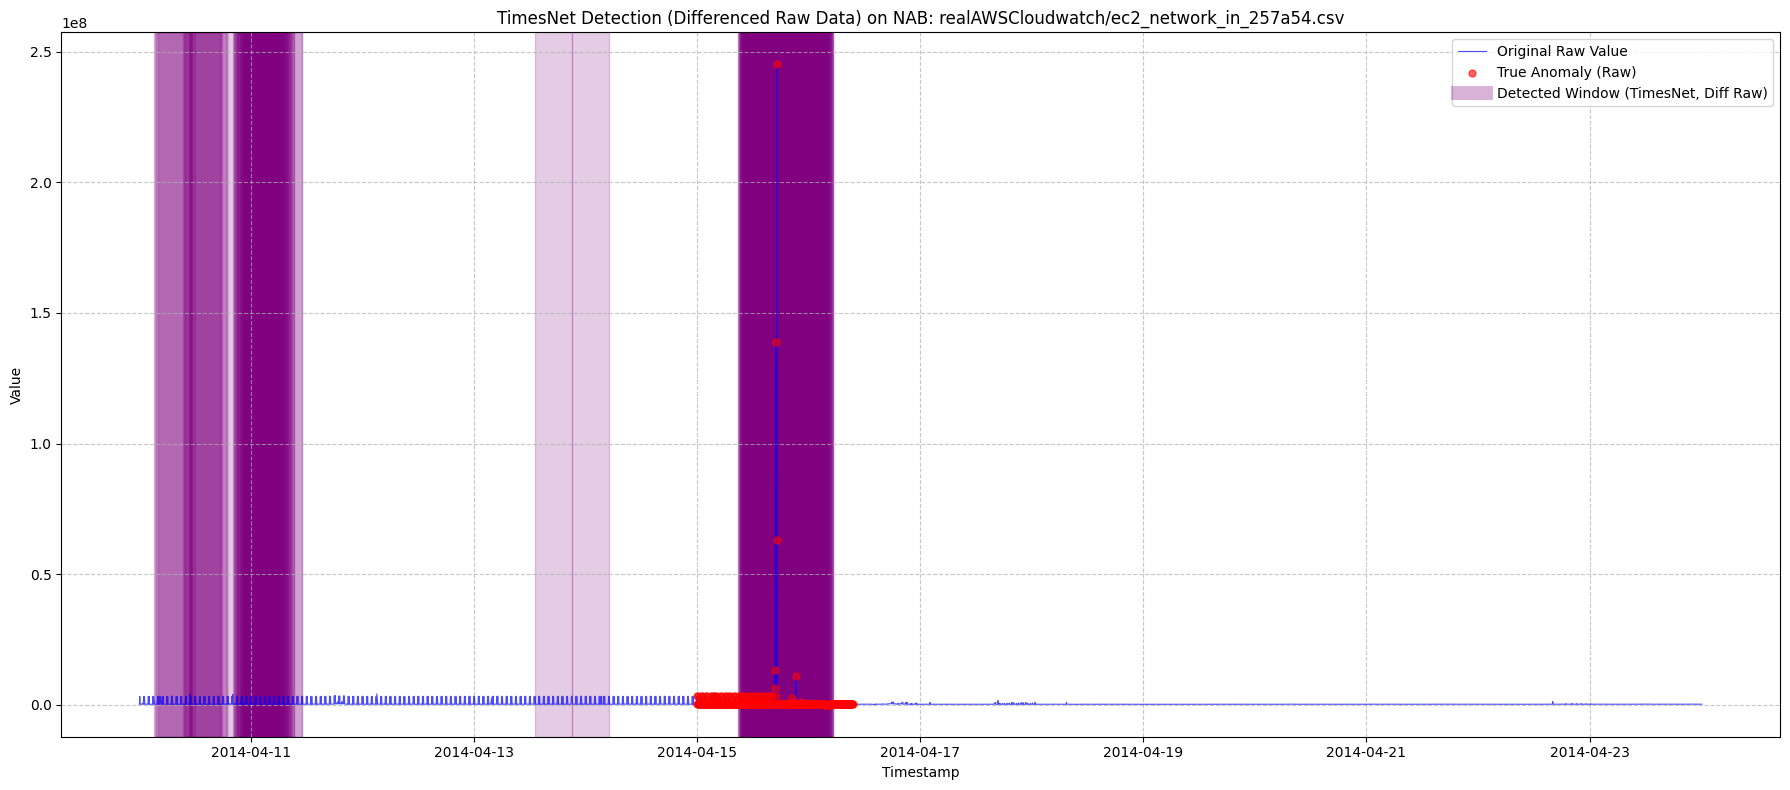

--- Visualization Complete ---

--- End of Script (with 1-Order Differencing Preprocessing) ---


In [11]:
# @title 8. 最终可视化 (原始数据上的异常窗口 - TimesNet) (修正缩进)
# ------------------------------------------------------------------------------
# 在 *原始* 数据上展示真实的异常区域和检测到的异常窗口
# 检测是基于 *差分* 数据进行的，但可视化在原始尺度上更直观
# !!! 需要特别注意时间戳对齐 !!!
# ------------------------------------------------------------------------------
print(f"\n--- Final Visualization (TimesNet on Raw Data with Detected Windows based on Differenced Data) ---")

# 定义一个简单的状态类来跟踪警告，避免重复打印
class FinalVisualizationState:
    printed_oob_warn = False

# 确保 原始data_df, 预测结果, 窗口信息 都有效
if (data_df is not None and not data_df.empty and 'value' in data_df.columns and # 原始数据
    WINDOW_SIZE is not None and
    'predicted_window_anomalies_bool_tsn' in locals() and predicted_window_anomalies_bool_tsn is not None and # 预测结果
    'X_windowed_data_np' in locals() and X_windowed_data_np is not None and X_windowed_data_np.shape[0] > 0 and # 窗口化数据
    len(predicted_window_anomalies_bool_tsn) == X_windowed_data_np.shape[0] and # 预测与窗口数量匹配
    'diff_order' in locals() and # 差分阶数已知
    len(data_df.index) > diff_order): # 原始数据足够长

    plt.figure(figsize=(18, 8))
    # 绘制原始数据值
    plt.plot(data_df.index, data_df['value'], label='Original Raw Value', color='blue', linewidth=0.8, alpha=0.7)

    # 标记原始数据中的真实异常区域
    if 'is_anomaly_pointwise' in data_df.columns:
        true_anomalies_plot = data_df[data_df['is_anomaly_pointwise'] == 1]
        if not true_anomalies_plot.empty:
            plt.scatter(true_anomalies_plot.index, true_anomalies_plot['value'], color='red', label='True Anomaly (Raw)', marker='o', s=25, alpha=0.6, zorder=3)

    # 标记TimesNet检测到的异常窗口 (需要对齐到原始数据的时间戳)
    num_windows_for_vis = X_windowed_data_np.shape[0]
    detected_marked = False

    # X_windowed_data_np 的第 i 个窗口对应于 *差分后* 序列的索引 i 到 i+WINDOW_SIZE-1
    # 差分后序列的第 i 个点对应于 *原始* 序列的第 i + diff_order 个点
    # 所以，窗口 i (在差分序列上) 对应于原始序列索引范围：
    # [i + diff_order] 到 [i + diff_order + WINDOW_SIZE - 1]

    for i in range(num_windows_for_vis):
        if predicted_window_anomalies_bool_tsn[i]:
            # 计算窗口在原始序列中的起始和结束索引
            original_start_idx = i + diff_order
            original_end_idx = i + diff_order + WINDOW_SIZE - 1

            # 确保索引在原始 data_df 的边界内
            if original_start_idx < len(data_df.index) and original_end_idx < len(data_df.index):
                window_start_time = data_df.index[original_start_idx]
                window_end_time = data_df.index[original_end_idx]
                plt.axvspan(window_start_time, window_end_time, color='purple', alpha=0.2, label='_nolegend_')
                detected_marked = True
            else:
                 # 仅在第一次出现越界时打印警告，避免刷屏
                 if not FinalVisualizationState.printed_oob_warn:
                      print(f"  Warning: Window index {i} (maps to original index {original_start_idx}-{original_end_idx}) goes out of bounds for plotting on raw data (len: {len(data_df.index)}). Some windows might not be shown fully.")
                      FinalVisualizationState.printed_oob_warn = True # 标记已打印

    # ****** 修正部分开始 ******
    # 以下绘图命令需要与 for 循环和 plt.figure 对齐，而不是缩进在 for 循环内部或 if detected_marked 内部

    if detected_marked:
        # 添加一个图例项给检测到的窗口 (如果至少标记了一个)
        # 这个 plt.plot 应该只在需要添加图例时执行一次，并且它的缩进是正确的（在 if detected_marked 下）
        plt.plot([], [], color='purple', alpha=0.3, linewidth=10, label=f'Detected Window (TimesNet, Diff Raw)')

    # 这些命令设置整个图表的属性，应该在主 if 块下，与 plt.figure 同级
    plt.title(f"TimesNet Detection (Differenced Raw Data) on NAB: {NAB_DATA_FILE_RELATIVE_PATH}")
    plt.xlabel("Timestamp")
    plt.ylabel("Value")
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    # ****** 修正部分结束 ******

else:
    # 这个 else 对应最外层的 if，缩进正确
    print("Skipping final visualization: prerequisites not met or inconsistent data.")
    # (添加一些调试信息帮助定位问题)
    print("  Debugging info for visualization skip:")
    print(f"    data_df usable: {data_df is not None and not data_df.empty and 'value' in data_df.columns}")
    print(f"    WINDOW_SIZE defined: {WINDOW_SIZE is not None if 'WINDOW_SIZE' in locals() else 'N/A'}")
    print(f"    Predictions available: {'predicted_window_anomalies_bool_tsn' in locals() and predicted_window_anomalies_bool_tsn is not None}")
    print(f"    Windowed data available: {'X_windowed_data_np' in locals() and X_windowed_data_np is not None and X_windowed_data_np.shape[0] > 0}")
    if 'predicted_window_anomalies_bool_tsn' in locals() and predicted_window_anomalies_bool_tsn is not None and 'X_windowed_data_np' in locals() and X_windowed_data_np is not None:
        print(f"    Preds length match windows: {len(predicted_window_anomalies_bool_tsn) == X_windowed_data_np.shape[0]}")
    print(f"    Diff order defined: {'diff_order' in locals()}")
    if data_df is not None and 'diff_order' in locals():
        print(f"    Raw data long enough for diff: {len(data_df.index) > diff_order}")


# 脚本结束提示
print(f"--- Visualization Complete ---")
print(f"\n--- End of Script (with {diff_order if 'diff_order' in locals() else 'N/A'}-Order Differencing Preprocessing) ---")